# GLM 공정성 개선
직교화(Custom), CorrelationRemover, Threshold Tuning

In [1]:
!pip install scikit-learn pandas numpy matplotlib fairlearn scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.0 MB/s eta 0:00:00


In [2]:
# 한글 폰트
import subprocess, matplotlib, matplotlib.font_manager as fm
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
fm._load_fontmanager(try_read_cache=False)
font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, average_precision_score, f1_score, precision_score, recall_score)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

In [5]:
BASE_PATH  = '/content/drive/MyDrive/Colab Notebooks/리스크 공모전'
GLM_PKL    = f'{BASE_PATH}/churn_model_glm_final.pkl'
DATA_PKL   = f'{BASE_PATH}/Health_Insurance_final.pkl'

target = 'is_churn'
age_col    = 'age'
AGE_BINS   = [0, 19, 29, 39, 49, 59, 69, 100]
AGE_LABELS = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
DROP_PCT   = 0.02   # 허용 PR-AUC 하락 비율 (실무 기준)
print("설정 완료")

설정 완료


### 공정성 및 성능 지표

In [6]:
# ===== 공정성 유틸 =====
from sklearn.linear_model import Ridge, LinearRegression

# 공정성 gap 지표
#  FPR Gap, TPR Gap, DP Gap, EO Gap (최종 best 선택 기준)
GAP_METRICS = ['FPR Gap', 'TPR Gap', 'DP Gap']
ALL_GAPS    = GAP_METRICS + ['EO Gap']           # sweep 계산용(EO=선택 기준)

def confusion_rates(y_true, y_pred):
    """(FPR, TPR, DP) 반환"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    sel = (tp + fp) / len(y_true) if len(y_true) else 0.0
    return fpr, tpr, sel

def group_rates(y_true, y_pred, groups, rate='fpr'):
    """그룹별 rate({'fpr'|'tpr'|'sel'}). 표본 10개 미만 / 단일클래스 그룹은 제외"""
    idx = {'fpr': 0, 'tpr': 1, 'sel': 2}[rate]
    groups = pd.Series(list(groups))
    rates = {}
    for g in sorted(groups.dropna().unique()):
        mask = (groups == g).values
        if mask.sum() < 10:
            continue
        yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
        if len(np.unique(yt)) < 2:
            continue
        rates[g] = round(confusion_rates(yt, yp)[idx], 4)
    return rates

def gap(rate_dict):
    """집단간 공정성 지표 격차 계산"""
    values = list(rate_dict.values())
    return round(max(values) - min(values), 4) if len(values) >= 2 else 0.0

def fairness_gaps(y_true, y_pred, groups):
    """FPR/TPR/DP/EO Gap 한 번에."""
    fpr = gap(group_rates(y_true, y_pred, groups, 'fpr'))
    tpr = gap(group_rates(y_true, y_pred, groups, 'tpr'))
    dp  = gap(group_rates(y_true, y_pred, groups, 'sel'))
    return {'FPR Gap': fpr, 'TPR Gap': tpr, 'DP Gap': dp, 'EO Gap': round(max(fpr, tpr), 4)}

def avg_gap(y_true, y_pred, sens_dict, metric):
    """민감변수 전체에 대한 metric gap 평균."""
    return round(np.mean([fairness_gaps(y_true, y_pred, g)[metric] for g in sens_dict.values()]), 4)

def perf_metrics(y_true, prob, pred):
    """성능 지표 dict."""
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'PR-AUC': round(average_precision_score(y_true, prob), 4),
            'F1': round(f1_score(y_true, pred, zero_division=0), 4),
            'Precision': round(precision_score(y_true, pred, zero_division=0), 4),
            'Recall': round(recall_score(y_true, pred, zero_division=0), 4),
            'FPR': round(fp / (fp + tn), 4)}

### 전처리 방법 2가지

In [7]:
# ----- 직교화 & R² -----
def feature_r2(cols, source, basis):
    """각 수치형 피처를 basis(age, gender)로 적합했을 때 R²(민감정보 함량). 내림차순 Series."""
    r2 = {}
    for col in cols:
        x = source[col].values.astype(float)
        if np.isnan(x).any() or np.std(x) == 0:
            r2[col] = 0.0
            continue
        pred = LinearRegression().fit(basis, x).predict(basis)
        ss_res = np.sum((x - pred) ** 2)
        ss_tot = np.sum((x - x.mean()) ** 2)
        r2[col] = round(max(0.0, 1 - ss_res / ss_tot), 4)
    return pd.Series(r2).sort_values(ascending=False)

def orthogonalize(X_train, X_test, cols, basis_tr, basis_te, source_train=None, source_test=None):
    """cols의 각 컬럼을 basis에 대한 잔차로 대체. source 미지정 시 X 사용."""
    source_train = X_train if source_train is None else source_train
    source_test  = X_test  if source_test  is None else source_test

    # sweep에서 함수 반복 호출 시 직교화 누적으로 인한 버그 방지
    X_train, X_test = X_train.copy(), X_test.copy()
    for col in cols:
        # 회귀값
        reg = Ridge(alpha=1.0).fit(basis_tr, source_train[col].values.astype(float))
        # 잔차값
        X_train[col] = source_train[col].values.astype(float) - reg.predict(basis_tr)
        X_test[col]  = source_test[col].values.astype(float)  - reg.predict(basis_te)
    return X_train, X_test

def r2_grid(r2_series, max_points=12):
    """직교화 대상 집합이 바뀌는 R²경계값들로 τ grid 구성."""
    values = sorted({round(float(v), 4) for v in r2_series.values if v > 0})
    grid = [0.0] + values[:-1] if len(values) >= 2 else [0.0] # 0일 경우 전부 직교화, base는 이미 표에 존재
    if len(grid) > max_points:
        quantiles = np.quantile(grid, np.linspace(0, 1, max_points))
        grid = sorted({round(float(q), 4) for q in quantiles})
    return grid

# ----- CorrelationRemover (fairlearn) -----
# 표준 CR은 민감변수를 drop하나, baseline과의 feature 일관성 위해 민감변수와 범주형 변수 유지
# CorrelationRemover로 수치형 피처만 decorrlate하고, 민감피처와 수치형 피처 유지
def fit_correlation_remover(X, num_cols, sens_df, alpha):
    from fairlearn.preprocessing import CorrelationRemover
    Z = X[num_cols].astype(float).copy() # 비민감 수치형 피처
    for c in sens_df.columns:
        Z[c] = sens_df[c].values
    cr = CorrelationRemover(sensitive_feature_ids=list(sens_df.columns), alpha=alpha) # 상관구조 train 학습
    cr.fit(Z)
    return cr

def apply_correlation_remover(cr, X, num_cols, sens_df):
    Z = X[num_cols].astype(float).copy()
    for c in sens_df.columns:
        Z[c] = sens_df[c].values
    X = X.copy()
    X[num_cols] = cr.transform(Z)   # 비민감 피처 decorrelate, 민감 피처 drop
    return X

# ----- sweep & 선택 -----
def run_sweep(fit_fn, grid, threshold, y_val, sens_val, base_prauc_val, drop_limit):
    """val(2018)으로 pr_auc 허용 하락 계산하여 test 누수 방지 test 예측은 base에 대해 표로 비교하기 위함"""
    rows = []
    for value in grid:
        prob_val, prob_test, n_cols = fit_fn(value)
        pred_val  = (prob_val >= threshold).astype(int)
        prauc_val = average_precision_score(y_val, prob_val) #pr_auc 계산
        row = {'param': value, 'n_cols': n_cols, 'PR-AUC': round(prauc_val, 4),
               'F1': round(f1_score(y_val, pred_val, zero_division=0), 4),
               'drop': round(base_prauc_val - prauc_val, 4),
               'ok': (base_prauc_val - prauc_val) <= drop_limit, # 0.02 허용 하락에 대해 ok 여부 표시
               'prob': prob_test, 'pred': (prob_test >= threshold).astype(int)} # test 예측
        for metric in ALL_GAPS:
            row[metric] = avg_gap(y_val, pred_val, sens_val, metric)
        rows.append(row)
    return rows

def sweep_table(rows, param_name):
    cols = ['param', 'n_cols', 'PR-AUC', 'F1', 'drop', 'ok'] + ALL_GAPS
    return (pd.DataFrame([{c: r[c] for c in cols} for r in rows])
              .rename(columns={'param': param_name}).set_index(param_name))

def best_feasible(rows, metric):
    """성능 유지(ok)하는 대상 중 해당 공정성 지표 gap 최소화"""
    feasible = [r for r in rows if r['ok']]
    return min(feasible, key=lambda r: r[metric]) if feasible else None

def pick_best_variant(orth_rows, cr_rows, metric):
    """CR(표준 방법)과 orthogonalization 최적 후보를 선택해 gap 더 낮은 방법 변환"""
    candidates = []
    for method, rows in [('Orth', orth_rows), ('CR', cr_rows)]:
        best = best_feasible(rows, metric)
        if best:
            candidates.append((method, best))
    return min(candidates, key=lambda kv: kv[1][metric]) if candidates else (None, None)

### 그래프 및 표

In [8]:
# ----- 비교표 (test(2019) 기준 값) -----
def build_variants(base_prob, base_pred, orth_rows, cr_rows):
    """Baseline과 전처리 방법 2가지(Orth/CR) + 공정성 지표별 최적 후보"""
    variants = {'Base': {'prob': base_prob, 'pred': base_pred, 'param': '-'}}
    for method, rows in [('Orth', orth_rows), ('CR', cr_rows)]:
        for metric in GAP_METRICS:
            best = best_feasible(rows, metric)
            if best is None:
                continue
            variants[f'{method}[{metric}]'] = {'prob': best['prob'], 'pred': best['pred'], 'param': best['param']}
    return variants

def comparison_table(variants, y_test, sens_dict):
    rows = []
    for name, v in variants.items():
        row = {'Model': name, 'param': v['param'], **perf_metrics(y_test, v['prob'], v['pred'])} # 성능 지표
        for metric in GAP_METRICS:
            row[metric] = avg_gap(y_test, v['pred'], sens_dict, metric) # 공정성 지표
        rows.append(row)
    return pd.DataFrame(rows).set_index('Model')

def style_table(df, higher_better, lower_better, caption, base_row='Base'):
    """열별 최적값 초록, baseline 노랑 강조."""
    def color_best(s):
        if s.name in higher_better: # 높을수록 좋은 지표: 최대값 초록 표시
            best = s == s.max()
        elif s.name in lower_better: # 낮을수록 좋은 지표: 최소값 초록 표시
            best = s == s.min()
        else:
            return ['color:black'] * len(s)
        return ['background-color:#d4edda;font-weight:bold;color:black' if v else 'color:black' for v in best]
    # baseline
    def highlight_base(d):
        style = pd.DataFrame('', index=d.index, columns=d.columns)
        if base_row in d.index:
            style.loc[base_row] = 'background-color:#fff3cd;color:black'
        return style
    fmt = {c: '{:.4f}' for c in df.columns if str(df[c].dtype).startswith(('float', 'int'))}
    return df.style.apply(color_best).apply(highlight_base, axis=None).format(fmt).set_caption(caption)

# ----- 그래프 -----
def plot_pareto(sweep_df, base_prauc, drop_limit, model_name, fname):
    """(좌) 공정성 Avg Gap vs τ, (우) PR-AUC vs τ."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for metric in ALL_GAPS:
        axes[0].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
    axes[0].set(xlabel='R² threshold τ', ylabel='Avg Gap (↓ 공정)', title=f'({model_name}) 공정성 Avg Gap')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)
    axes[1].plot(sweep_df.index, sweep_df['PR-AUC'], marker='o', color='#1f77b4')
    axes[1].axhline(base_prauc, ls='--', color='#ff7f0e', label=f'Base={base_prauc:.4f}')
    axes[1].axhline(base_prauc - drop_limit, ls=':', color='#d62728', label='허용 하한')
    axes[1].set(xlabel='R² threshold τ', ylabel='PR-AUC (↑ 성능)', title=f'({model_name}) 성능')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.savefig(fname, dpi=200, bbox_inches='tight'); plt.show()

def plot_group_bars(y_test, sens_dict, series, title, fname, rate='fpr', colors=None):
    """민감변수별 시각화"""
    rate_label = {'fpr': 'FPR (Predictive Equality)', 'tpr': 'TPR (Equal Opportunity)',
                  'sel': 'Selection Rate (Demographic Parity)'}[rate]
    colors = colors or ['#cfcfcf', '#9ecae1', '#a1d99b', '#f4a582']
    variables = list(sens_dict)
    ncol = 3
    nrow = int(np.ceil(len(variables) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 3.7 * nrow))
    axes = np.array(axes).reshape(-1)
    width = 0.8 / len(series)
    for ax, var in zip(axes, variables):
        groups = sens_dict[var]
        rate_by_series = []
        for label, preds in series:
            pred = preds[var]['pred'] if isinstance(preds, dict) else preds
            rate_by_series.append((label, group_rates(y_test, pred, groups, rate)))
        group_labels = sorted(set().union(*[set(r) for _, r in rate_by_series]))
        x = np.arange(len(group_labels))
        for i, (label, rates) in enumerate(rate_by_series):
            offset = (i - (len(series) - 1) / 2) * width
            ax.bar(x + offset, [rates.get(g, 0) for g in group_labels], width, label=label,
                   color=colors[i % len(colors)], edgecolor='#5a5a5a', linewidth=0.4)
        gap_text = ' / '.join(f"{label[:1]}{gap(rates):.2f}" for label, rates in rate_by_series)
        ax.set_title(f"{var}  Gap {gap_text}", fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(group_labels, rotation=30, ha='right', fontsize=7)
        ax.set_ylabel(rate_label, fontsize=7)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=6)
    for ax in axes[len(variables):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

# ----- 민감변수별 요약표 (Base / 전처리 best / 후처리) -----
def per_variable_tables(y_test, sens_dict, rows, model_name, orth_tau=None):
    """민감변수별 표 1개씩(총 6개)"""
    lower_better  = ['DP Gap', 'FPR Gap', 'TPR Gap']
    higher_better = ['F1']
    tables = {}
    for var in sens_dict:
        groups = sens_dict[var]
        table_rows = []
        for label, preds in rows:
            if isinstance(preds, dict):
                pred = preds[var]['pred']
                name = label if preds[var].get('used', True) else f'{label} (revert)'
            else:
                pred, name = preds, label
            g = fairness_gaps(y_test, pred, groups) # 공정성 지표 (test)
            table_rows.append({'Model': name, 'DP Gap': g['DP Gap'], 'FPR Gap': g['FPR Gap'],
                               'TPR Gap': g['TPR Gap'],
                               'F1': round(f1_score(y_test, pred, zero_division=0), 4)})
        df = pd.DataFrame(table_rows).set_index('Model')
        caption = f"[{model_name}] {var} — Base / 전처리 / 후처리 (DP·FPR·TPR Gap·F1)"
        if orth_tau is not None:
            caption += f" | Orth τ={orth_tau}"
        tables[var] = df
        display(style_table(df, higher_better, lower_better, caption))
    return tables

### 후처리 함수

In [9]:
# ----- 후처리 방법 3가지 -----
# 방법 1
def tune_thresholds_fpr(prob_val, y_val, sens_val, prob_test, sens_test,
                        default_thr, rate='fpr', worsen_tol=0.01):
    """
    방법1) FPR 균등화(+악화 시 원복).
    val(2018)에서 그룹별 음성(y=0) 확률 분위수를 임계값으로 산출하여
    keep/revert(악화 시 공통 임계값 적용) 판단한 뒤, 확정된 임계값 test에 적용"""
    y_val = np.asarray(y_val)
    results = {}
    for var in sens_val:
        groups_val  = np.asarray(sens_val[var])
        groups_test = np.asarray(sens_test[var])
        if rate == 'fpr':
            neg = (y_val == 0)
            # 모든 그룹이 전체 FPR을 갖도록 target으로 함
            target = float((prob_val[neg] >= default_thr).mean()) if neg.sum() else 0.0
        else:
            target = float((prob_val >= default_thr).mean())
        group_thr = {}
        for g in pd.unique(groups_val):
            mask = (groups_val == g)
            if mask.sum() < 10:
                continue
            # quantile - 그룹별 임계값 산출 (e.g. fpr =0.3으로 맞추려면 그 그룹 음성들의 70번째 백분위수를 임계값으로 잡음)
            pool = prob_val[mask & (y_val == 0)] if rate == 'fpr' else prob_val[mask]
            group_thr[g] = float(np.quantile(pool, 1 - target)) if len(pool) else default_thr
        def apply_thr(prob, groups):
            out = (prob >= default_thr).astype(int)
            for g, t in group_thr.items():
                m = (groups == g)
                out[m] = (prob[m] >= t).astype(int)
            return out
        # 그룹별 튜닝이 gap을 키울 경우(소표본, 분포 특성 등 원인), 공통 임계값으로 revert
        gap_before = gap(group_rates(y_val, (prob_val >= default_thr).astype(int), pd.Series(groups_val), rate))
        gap_after  = gap(group_rates(y_val, apply_thr(prob_val, groups_val),        pd.Series(groups_val), rate))
        keep = gap_after < gap_before + worsen_tol
        pred_test = apply_thr(prob_test, groups_test) if keep else (prob_test >= default_thr).astype(int)
        results[var] = {'pred': pred_test, 'used': keep}
    return results

# 방법 2
def tune_thresholds_equalized_odds(estimator, X_val, y_val, sens_val, X_test, sens_test, fallback_pred):
    """
    방법2) fairlearn ThresholdOptimizer(equalized_odds), 실패(그룹 구성 문제 등) 시 방법 2 적용되지 않음"""
    from fairlearn.postprocessing import ThresholdOptimizer
    results = {}
    for var in sens_test:
        try:
            opt = ThresholdOptimizer(estimator=estimator, constraints='equalized_odds',
                                     objective='balanced_accuracy_score', prefit=True,
                                     predict_method='predict_proba')
            opt.fit(X_val, y_val, sensitive_features=np.asarray(sens_val[var])) # val로 그룹별 임계값 학습
            pred = opt.predict(X_test, sensitive_features=np.asarray(sens_test[var]), random_state=42) # test에 적용
            results[var] = {'pred': pred, 'used': True}
        except Exception as e:
            print(f"  [ThresholdOptimizer {var}] 실패: {e}")
            results[var] = {'pred': fallback_pred, 'used': False}
    return results

def tune_thresholds_f1max(prob_val, y_val, sens_val, prob_test, sens_test, default_thr):
    """
    방법3) 그룹별 val F1 최대 임계값을 test에 적용"""
    y_val = np.asarray(y_val)
    grid = np.linspace(0.02, 0.98, 49) # 49개 후보 임계값
    results = {}
    for var in sens_val:
        groups_val  = np.asarray(sens_val[var])
        groups_test = np.asarray(sens_test[var])
        group_thr = {}
        for g in pd.unique(groups_val):
            mask = (groups_val == g)
            if mask.sum() < 10:
                continue
            p, y = prob_val[mask], y_val[mask]
            if len(np.unique(y)) < 2:
                group_thr[g] = default_thr # 공통 임계값
                continue
            f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in grid]
            group_thr[g] = float(grid[int(np.argmax(f1s))]) # 각 그룹에서 f1 최대인 t 선택
        pred = (prob_test >= default_thr).astype(int)
        for g, t in group_thr.items():
            m = (groups_test == g)
            pred[m] = (prob_test[m] >= t).astype(int)
        results[var] = {'pred': pred, 'used': True}
    return results

### 1. glm baseline 및 데이터 로드

In [10]:
with open(GLM_PKL, 'rb') as f:
    glm_pkg = pickle.load(f)
glm_model   = glm_pkg['model']
glm_thr     = float(glm_pkg['threshold'])
glm_xcols   = glm_pkg['features']['x_cols']
glm_numcols = glm_pkg['features']['num_cols']
glm_catcols = glm_pkg['features']['cat_cols']
base_lr     = glm_model.named_steps['model']

def make_glm_pipeline():
    """Baseline 동일 파이프라인 구성 (class_weight 없음)"""
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), glm_numcols),
        ('cat', OneHotEncoder(drop='first'), glm_catcols),
    ])
    # baseline 하이퍼파라미터 재구성
    lr = LogisticRegression(
        C=base_lr.C, l1_ratio=base_lr.l1_ratio, penalty=base_lr.penalty,
        solver=base_lr.solver, max_iter=base_lr.max_iter, random_state=base_lr.random_state,
        n_jobs=base_lr.n_jobs, fit_intercept=base_lr.fit_intercept, class_weight=None,
    )
    return Pipeline([('preprocessor', preprocessor), ('model', lr)])

def glm_prob(X):
    """GLM 양성 확률 (multi_class 이슈  발생 시 decision_function 우회)."""
    try:
        return glm_model.predict_proba(X)[:, 1]
    except AttributeError:
        return expit(glm_model.decision_function(X))

print(f"GLM threshold={glm_thr:.4f}, num_cols {len(glm_numcols)}, cat_cols {len(glm_catcols)}")
print(glm_numcols); print(glm_catcols)

GLM threshold=0.1400, num_cols 15, cat_cols 7
['premium', 'seniority_policy', 'log_cost_claims_year', 'age', 'IICIMUN_capped', 'IICIPROV', 'C_H_num', 'C_GI', 'C_IE_T', 'missing_geo_cxt', 'high_loss', 'relative_poverty', 'kr_premium_shock', 'kr_economic_stress', 'kr_medical_desert']
['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']


In [11]:
with open(DATA_PKL, 'rb') as f:
    data = pickle.load(f)
train = data[data['period'].isin([2017, 2018])]
test  = data[data['period'] == 2019]
y_train, y_test = train[target], test[target]
print(f"train={train.shape}, test={test.shape}")

train=(150999, 43), test=(75667, 43)


In [12]:
str_cast = {c: str for c in glm_catcols}
x_train_glm = train[glm_xcols].astype(str_cast)
x_test_glm  = test[glm_xcols].astype(str_cast)

# R^2 및 직교화용 수치형 프레임 (float)
x_train_glm_num = x_train_glm[glm_numcols].astype(float)
x_test_glm_num  = x_test_glm[glm_numcols].astype(float)
print(f"x_train_glm={x_train_glm.shape}")

x_train_glm=(150999, 22)


In [13]:
prob_glm_base = glm_prob(x_test_glm)
pred_glm_base = (prob_glm_base >= glm_thr).astype(int)
print("=== GLM Base ===")
for k, v in perf_metrics(y_test, prob_glm_base, pred_glm_base).items():
    print(f"  {k}: {v}")

=== GLM Base ===
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019


### 2. 직교화 기저 생성 및 R²계산

In [14]:
# 직교화 기저: age_group 더미 + gender + age×gender + age(연속형) + age²
train_ag = pd.cut(train[age_col], bins=AGE_BINS, labels=AGE_LABELS)
test_ag  = pd.cut(test[age_col],  bins=AGE_BINS, labels=AGE_LABELS)

age_encoder  = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
# 기준인 10s 제외하고 6열 구성의 라벨을 원핫 숫자로 바꿈(회귀 기저에 넣기 위함)
age_dummy_tr = age_encoder.fit_transform(train_ag.values.reshape(-1, 1))
age_dummy_te = age_encoder.transform(test_ag.values.reshape(-1, 1))

gender_ref = train['gender'].astype(str).unique()[1]
gender_tr = (train['gender'].astype(str) == gender_ref).astype(float).values.reshape(-1, 1)
gender_te = (test['gender'].astype(str)  == gender_ref).astype(float).values.reshape(-1, 1)

interact_tr = age_dummy_tr * gender_tr           # age×gender 교호작용(곱 term)
interact_te = age_dummy_te * gender_te

age_tr = train[age_col].values.astype(float).reshape(-1, 1)
age_te = test[age_col].values.astype(float).reshape(-1, 1)
age_mean, age_std = age_tr.mean(), age_tr.std()
# age 표준화(직교화는 ridge라 l2 벌점이 계수 크기에 민감하기에 벌점 공정성을 위해 기저 열들의 스케일 맞춰줌)
age_z_tr = (age_tr - age_mean) / age_std
age_z_te = (age_te - age_mean) / age_std

basis_tr = np.hstack([age_dummy_tr, gender_tr, interact_tr, age_z_tr, age_z_tr ** 2])
basis_te = np.hstack([age_dummy_te, gender_te, interact_te, age_z_te, age_z_te ** 2])
print(f"기저 행렬 train={basis_tr.shape}")

기저 행렬 train=(150999, 15)


In [15]:
# 기저를 구성하는 데 쓰인 age, gender는 민감변수면서, 직교화에 넣으면 잔차가 0이 되어 무의미하므로 직교화 대상에서 제외
glm_decorr_cols = [c for c in glm_numcols if c not in ('age', 'gender')]
r2_glm_series = feature_r2(glm_decorr_cols, x_train_glm_num, basis_tr)
print("GLM Feature별 기저와의 R²:")
print(r2_glm_series.to_string())

GLM Feature별 기저와의 R²:
kr_premium_shock        0.9194
seniority_policy        0.2405
premium                 0.1998
log_cost_claims_year    0.0603
C_IE_T                  0.0246
C_H_num                 0.0245
C_GI                    0.0132
high_loss               0.0108
IICIMUN_capped          0.0101
relative_poverty        0.0080
missing_geo_cxt         0.0056
kr_medical_desert       0.0050
kr_economic_stress      0.0026
IICIPROV                0.0018


### 3. 민감변수 그룹

In [16]:
# 민감변수 그룹: age_group / gender / age_gender / c_h / c_gi / c_ie_t
AG_BINS, AG_LABELS = [0, 25, 40, 60, 100], ['청년', '중년', '장년', '고령']
age_gender_tr = pd.cut(train[age_col], AG_BINS, labels=AG_LABELS).astype(str) + '_' + train['gender'].astype(str)
age_gender_te = pd.cut(test[age_col],  AG_BINS, labels=AG_LABELS).astype(str) + '_' + test['gender'].astype(str)

# C_GI(소득 수), C_IE_T(교육 수): 4구간+Unknown
# C_H_num(인구 규모 분류): 금액코드→라벨
SENS_CONFIG = {
    'C_GI':    {'bins': [-2, 0, 25, 50, 75, 100], 'labels': ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']},
    'C_IE_T':  {'bins': [-2, 0, 25, 50, 75, 100], 'labels': ['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']},
    'C_H_num': {'map': {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}},
}
for col, cfg in SENS_CONFIG.items():
    for df in [train, test]:
        if 'bins' in cfg:
            grp = pd.cut(df[col], bins=cfg['bins'], labels=cfg['labels'])
            df[f'{col}_grp'] = grp.astype(str).replace('nan', np.nan)
        else:
            df[f'{col}_grp'] = df[col].map(cfg['map']).fillna('Unknown')

def build_sensitive(df, age_group, age_gender):
    return {'age_group': age_group, 'gender': df['gender'].astype(str), 'age_gender': age_gender,
            'c_h': df['C_H_num_grp'], 'c_gi': df['C_GI_grp'], 'c_ie_t': df['C_IE_T_grp']}

sensitive_test  = build_sensitive(test,  test_ag,  age_gender_te)
sensitive_train = build_sensitive(train, train_ag, age_gender_tr)
for k, v in sensitive_test.items():
    print(f"  {k:12s}: {sorted(pd.Series(v).dropna().unique())}")

  age_group   : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
  gender      : ['F', 'M']
  age_gender  : ['고령_F', '고령_M', '장년_F', '장년_M', '중년_F', '중년_M', '청년_F', '청년_M']
  c_h         : ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'Unknown']
  c_gi        : ['GI_1', 'GI_2', 'GI_3', 'GI_4', 'Unknown']
  c_ie_t      : ['C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4', 'Unknown']


In [17]:
# validation = 2018 (직교화 best 재적합용 + 후처리 threshold tuning)
# baseline / ortogonalization 모델은 2017/2018로 학습 → 2018은 학습에 포함된(in-sample) 검증
val_mask = (train['period'] == 2018).values
y_val = y_train[val_mask]
sensitive_val = {k: v[val_mask] for k, v in sensitive_train.items()}
print(f"validation(2018) n={int(val_mask.sum())}")

validation(2018) n=73474


### baseline 민감변수별 성능 및 공정성 지표

In [18]:
def sens_report(var, y_true, prob, pred, sens_dict):
    g = pd.Series(list(sens_dict[var]))
    rows = {}
    for k in sorted(g.dropna().unique()):
        m = (g == k).values
        yt = np.asarray(y_true)[m]
        if m.sum() < 10 or len(np.unique(yt)) < 2:
            continue
        yp = np.asarray(pred)[m]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows[k] = {'n': int(m.sum()), 'selection_rate': (tp + fp) / len(yt),
                   'tpr': tp / (tp + fn), 'tnr': tn / (tn + fp),
                   'fpr': fp / (fp + tn), 'fnr': fn / (fn + tp)}
    df = pd.DataFrame(rows).T
    print(f"===== [{var}] 그룹별 공정성 세부 =====")
    print("----- 전체 성능 -----")
    for kk, vv in perf_metrics(y_true, prob, pred).items():
        print(f"  {kk}: {vv}")
    print("----- 집단 간 최대 격차 (max-min) -----")
    for c in ['selection_rate', 'tpr', 'tnr', 'fpr', 'fnr']:
        print(f"  {c:15s}: {round(df[c].max() - df[c].min(), 4)}")
    return df

- 성별

In [19]:
sens_report('gender', y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [gender] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.0818
  tpr            : 0.0428
  tnr            : 0.0886
  fpr            : 0.0886
  fnr            : 0.0428


,n,selection_rate,tpr,tnr,fpr,fnr
F,41143.0,0.510464,0.766641,0.538439,0.461561,0.233359
M,34524.0,0.592226,0.809464,0.449834,0.550166,0.190536


- 연령대

In [ ]:
sens_report('age_group', y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [age_group] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.7195
  tpr            : 0.6236
  tnr            : 0.7147
  fpr            : 0.7147
  fnr            : 0.6236


,n,selection_rate,tpr,tnr,fpr,fnr
10s,13000.0,0.856077,0.938854,0.167291,0.832709,0.061146
20s,6650.0,0.766165,0.899787,0.269693,0.730307,0.100213
30s,12126.0,0.713013,0.845509,0.321484,0.678516,0.154491
40s,12078.0,0.618645,0.783427,0.416516,0.583484,0.216573
50s,10004.0,0.472911,0.736921,0.567851,0.432149,0.263079
60s,10094.0,0.274916,0.608187,0.755926,0.244074,0.391813
70s+,11715.0,0.136577,0.315217,0.882009,0.117991,0.684783


- 성별_연령대

In [ ]:
sens_report('age_gender',   y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [age_gender] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.6663
  tpr            : 0.5162
  tnr            : 0.6634
  fpr            : 0.6634
  fnr            : 0.5162


,n,selection_rate,tpr,tnr,fpr,fnr
고령_F,11922.0,0.178410,0.419517,0.843521,0.156479,0.580483
고령_M,8988.0,0.211059,0.439535,0.813115,0.186885,0.560465
장년_F,11730.0,0.490026,0.729609,0.553119,0.446881,0.270391
장년_M,9890.0,0.595854,0.796968,0.440583,0.559417,0.203032
중년_F,9175.0,0.678801,0.826687,0.361269,0.638731,0.173313
중년_M,7289.0,0.767869,0.887029,0.261315,0.738685,0.112971
청년_F,8316.0,0.829606,0.925067,0.197802,0.802198,0.074933
청년_M,8357.0,0.844681,0.935718,0.180116,0.819884,0.064282


- c_h (소득수준)

In [ ]:
sens_report('c_h', y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [c_h] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.2139
  tpr            : 0.145
  tnr            : 0.2158
  fpr            : 0.2158
  fnr            : 0.145


,n,selection_rate,tpr,tnr,fpr,fnr
H1,843.0,0.545670,0.714286,0.480164,0.519836,0.285714
H2,7662.0,0.664839,0.848138,0.375997,0.624003,0.151862
H3,9621.0,0.637875,0.828526,0.408182,0.591818,0.171474
H4,6207.0,0.683100,0.859309,0.358566,0.641434,0.140691
H5,6430.0,0.652411,0.849379,0.396927,0.603073,0.150621
H6,42594.0,0.469198,0.730921,0.574382,0.425618,0.269079
Unknown,2310.0,0.578788,0.830769,0.453171,0.546829,0.169231


- c_gi (인구 규모)

In [ ]:
sens_report('c_gi',   y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [c_gi] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.2577
  tpr            : 0.1791
  tnr            : 0.249
  fpr            : 0.249
  fnr            : 0.1791


,n,selection_rate,tpr,tnr,fpr,fnr
GI_1,1859.0,0.708445,0.898219,0.342428,0.657572,0.101781
GI_2,6361.0,0.741236,0.903182,0.307740,0.692260,0.096818
GI_3,10875.0,0.715954,0.894783,0.331510,0.668490,0.105217
GI_4,53519.0,0.483585,0.724093,0.556778,0.443222,0.275907
Unknown,3053.0,0.572879,0.827195,0.460370,0.539630,0.172805


- c_ie_t (교육수준)

In [ ]:
sens_report('c_ie_t', y_test, prob_glm_base, pred_glm_base, sensitive_test)

===== [c_ie_t] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.3432
  F1: 0.3575
  Precision: 0.2314
  Recall: 0.7863
  FPR: 0.5019
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.3364
  tpr            : 0.2657
  tnr            : 0.3257
  fpr            : 0.3257
  fnr            : 0.2657


,n,selection_rate,tpr,tnr,fpr,fnr
C_IE_T_1,18088.0,0.727941,0.898811,0.317276,0.682724,0.101189
C_IE_T_2,18133.0,0.601555,0.820342,0.444548,0.555452,0.179658
C_IE_T_3,18164.0,0.467243,0.710476,0.573846,0.426154,0.289524
C_IE_T_4,18229.0,0.391519,0.633128,0.642951,0.357049,0.366872
Unknown,3053.0,0.572879,0.827195,0.460370,0.539630,0.172805


### 방법론 — 직교화(Custom) & CorrelationRemover(표준)

**보호속성과 basis**

- 직접적 보호속성은 age, gender / 지역 및 소득 변수(C_H_num, C_GI, C_IE_T)는 자체가 보호속성이 아니라 age, gender를 간접적으로 담을 수 있는 대리변수(proxy)
- 각 수치형 피처에서 basis(보호속성 기저)로 설명되는 간접차별 성분을 제거하고자, basis는 age, gender로 구성 -> age_group 더미 + gender + age×gender + age(연속형) + age(연속형)^2

1. **CorrelationRemover (표준, fairlearn)** — 비민감 피처를 민감 피처로 선형회귀한 잔차로 대체(`alpha`로 강도 조절)하며, 전 수치형 피처에 적용
2. **Custom 직교화** — 비선형 basis로 잔차화하되, 민감정보 함량(R^2)이 임계 τ를 넘는(R^2 > Tau) 피처만 선택적 직교화

- 하이퍼파라미터(τ, alpha, best 방법)와 후처리 임계값은 모두 val(2018)으로 선택
- 최종 결과는 test(2019)로 하므로 데이터 누수 X
- PR-AUC 하락 ≤ Baseline val(2018)의 PR-AUC×0.02
- 단 baseline과 ortho 모델이 2017+2018로 train되어 2018이 학습에 포함되므로 val은 완전 독립 holdout은 아닌 게 방법론의 한계임

---
**지표 설명**
- alpha : correlationremover는 수치형 피처(14개)에 대해 decorrelate하는 강도 (0~1, 0이 피처 원본 = baseline과 동일)
- tau : baseline의 validation set(2018)의 PR-AUC = `0.4590` 기준으로 2% 하락(실무 기준)만 허용하는 값 (tau = 0 은 R^2 > 0 인 피처 전부 직교화 -> 최대 직교화)
- n_cols :  tau 값에 따른 직교화 변수 개수 (correlationremover은 전 수치형 피처 모두 적용하므로 항상 14개)
- F1 : validation set 기준 f1 score
- ok : 허용 하락 범위 안에 들어오는지 여부(False/True)
- FPR/TPR/DP/EO Gap : 민감변수 6개 Gap (max-min) 의 평균

In [ ]:
# CorrelationRemover (val 기준 alpha 선택)
gender_code_tr = (train['gender'].astype(str) == gender_ref).astype(float).values
gender_code_te = (test['gender'].astype(str)  == gender_ref).astype(float).values
sens_df_tr = pd.DataFrame({'age': train[age_col].astype(float).values, 'gender': gender_code_tr})
sens_df_te = pd.DataFrame({'age': test[age_col].astype(float).values,  'gender': gender_code_te})
cr_cols = [c for c in glm_numcols if c != 'age']   # age는 민감변수니까 제외, gender는 범주형이라 numcols에 없음

def fit_cr_glm(alpha):
    cr = fit_correlation_remover(x_train_glm, cr_cols, sens_df_tr, alpha) # train - 상관구조 학습
    X_tr = apply_correlation_remover(cr, x_train_glm, cr_cols, sens_df_tr) # train 피처 decorrelate
    X_te = apply_correlation_remover(cr, x_test_glm,  cr_cols, sens_df_te) # test 피처 decorrelate
    model = make_glm_pipeline()
    model.fit(X_tr, y_train)
    prob_val  = model.predict_proba(X_tr)[:, 1][val_mask] # 선택
    prob_test = model.predict_proba(X_te)[:, 1] # 평가
    return prob_val, prob_test, len(cr_cols)

cr_rows = run_sweep(fit_cr_glm, np.round(np.linspace(0, 1, 6), 2), glm_thr, y_val, sensitive_val, base_prauc_val, drop_limit) # alpha grid = [0, 0.2, 0.4, 0.6, 0.8, 1]
print("CorrelationRemover alpha sweep:")
display(sweep_table(cr_rows, 'alpha'))

CorrelationRemover alpha sweep:


,n_cols,PR-AUC,F1,drop,ok,FPR Gap,TPR Gap,DP Gap,EO Gap
alpha,,,,,,,,,
0.0,14,0.4590,0.4138,0.0000,True,0.3754,0.2983,0.3904,0.3754
0.2,14,0.4583,0.4140,0.0007,True,0.3795,0.2988,0.3938,0.3795
0.4,14,0.4576,0.4136,0.0013,True,0.3816,0.2965,0.3951,0.3816
0.6,14,0.4573,0.4133,0.0016,True,0.3810,0.2956,0.3945,0.3810
0.8,14,0.4568,0.4127,0.0021,True,0.3814,0.2921,0.3945,0.3814
1.0,14,0.4566,0.4127,0.0024,True,0.3808,0.2893,0.3940,0.3808


In [ ]:
# baseline f1_score과 correlationremover (alpha=1)의 fl_score 일치함
prob_base_val = glm_prob(x_train_glm)[val_mask]
pred_base_val = (prob_base_val >= glm_thr).astype(int)
print('GLM base val F1 :', round(f1_score(y_val, pred_base_val, zero_division=0), 4))

Base PR-AUC(val)=0.4590, 허용 하락=0.0092 (2%)


,n_cols,PR-AUC,F1,drop,ok,FPR Gap,TPR Gap,DP Gap,EO Gap
τ,,,,,,,,,
0.0000,14,0.4525,0.4136,0.0065,True,0.3499,0.2612,0.3727,0.3518
0.0019,13,0.4527,0.4134,0.0062,True,0.3492,0.2611,0.3715,0.3508
0.0035,12,0.4527,0.4134,0.0062,True,0.3492,0.2611,0.3715,0.3508
0.0053,11,0.4527,0.4134,0.0062,True,0.3492,0.2611,0.3715,0.3508
0.0073,10,0.4527,0.4135,0.0063,True,0.3483,0.2619,0.3751,0.3506
0.0099,9,0.4526,0.4132,0.0064,True,0.3474,0.2635,0.3798,0.3502
0.0110,7,0.4528,0.4134,0.0062,True,0.3458,0.2613,0.3778,0.3482
0.0163,6,0.4528,0.4134,0.0062,True,0.3458,0.2613,0.3778,0.3482
0.0245,5,0.4528,0.4134,0.0062,True,0.3459,0.2618,0.3782,0.3482


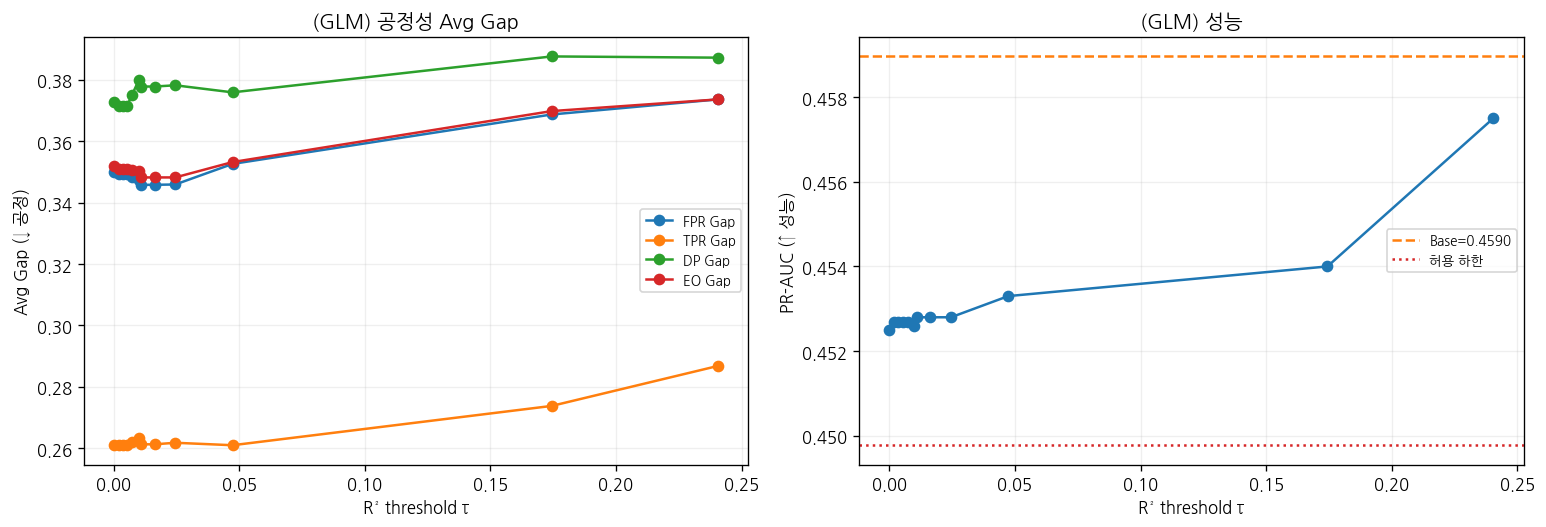

In [ ]:
# Custom 직교화 (val 기준 tau 선택)
base_prauc_val = average_precision_score(y_val, glm_prob(x_train_glm)[val_mask])
drop_limit = base_prauc_val * DROP_PCT
print(f"Base PR-AUC(val)={base_prauc_val:.4f}, 허용 하락={drop_limit:.4f} ({DROP_PCT:.0%})")

def fit_orth_glm(tau):
    cols = r2_glm_series[r2_glm_series > tau].index.tolist()
    X_tr, X_te = orthogonalize(x_train_glm, x_test_glm, cols, basis_tr, basis_te,
                               x_train_glm_num, x_test_glm_num)
    model = make_glm_pipeline()
    model.fit(X_tr, y_train)
    prob_val  = model.predict_proba(X_tr)[:, 1][val_mask]
    prob_test = model.predict_proba(X_te)[:, 1]
    return prob_val, prob_test, len(cols)

orth_rows = run_sweep(fit_orth_glm, r2_grid(r2_glm_series), glm_thr, y_val, sensitive_val, base_prauc_val, drop_limit)
sweep = sweep_table(orth_rows, 'τ')   # gap, PR-AUC는 val 기준
display(sweep)
plot_pareto(sweep, base_prauc_val, drop_limit, 'GLM', 'pareto_glm.png')

## 전처리 및 공정성 지표 조합별 최적 선택

In [ ]:
variants = build_variants(prob_glm_base, pred_glm_base, orth_rows, cr_rows)
cmp = comparison_table(variants, y_test, sensitive_test)
higher = ['PR-AUC', 'F1', 'Precision', 'Recall'] # 높을수록 good
lower  = ['FPR', 'FPR Gap', 'TPR Gap', 'DP Gap'] # 낮을수록 good
display(style_table(cmp, higher, lower,
                    "GLM - Orth, CR × 성능 및 공정성 지표별 (gap 작을수록 공정, 성능 유지)"))

,param,PR-AUC,F1,Precision,Recall,FPR,FPR Gap,TPR Gap,DP Gap
Model,,,,,,,,,
Base,-,0.3432,0.3575,0.2314,0.7863,0.5019,0.3762,0.2954,0.3792
Orth[FPR Gap],0.011000,0.3432,0.3555,0.2284,0.8013,0.5202,0.3545,0.2334,0.3519
Orth[TPR Gap],0.047300,0.3440,0.3554,0.2283,0.8014,0.5204,0.3608,0.2381,0.3579
Orth[DP Gap],0.001900,0.3430,0.3559,0.2288,0.8003,0.5182,0.3578,0.2348,0.3550
CR[FPR Gap],0.000000,0.3432,0.3575,0.2314,0.7863,0.5019,0.3762,0.2954,0.3792
CR[TPR Gap],1.000000,0.3414,0.3532,0.2258,0.8104,0.5340,0.3926,0.2758,0.3901
CR[DP Gap],0.000000,0.3432,0.3575,0.2314,0.7863,0.5019,0.3762,0.2954,0.3792


### Best 모델 — 민감변수별 그룹 지표 (Baseline vs Best)
- val 기준으로 생성된 표에서 EO Gap이 최소인 tau 선택 (동률 후보 중 보호속성과 proxy를 가장 많이 제거하는 tau인 가장 작은 tau 선택하도록 설계)

GLM Best = Orth (τ=0.011) | 선택기준 val: EO Gap=0.3482, F1=0.4134


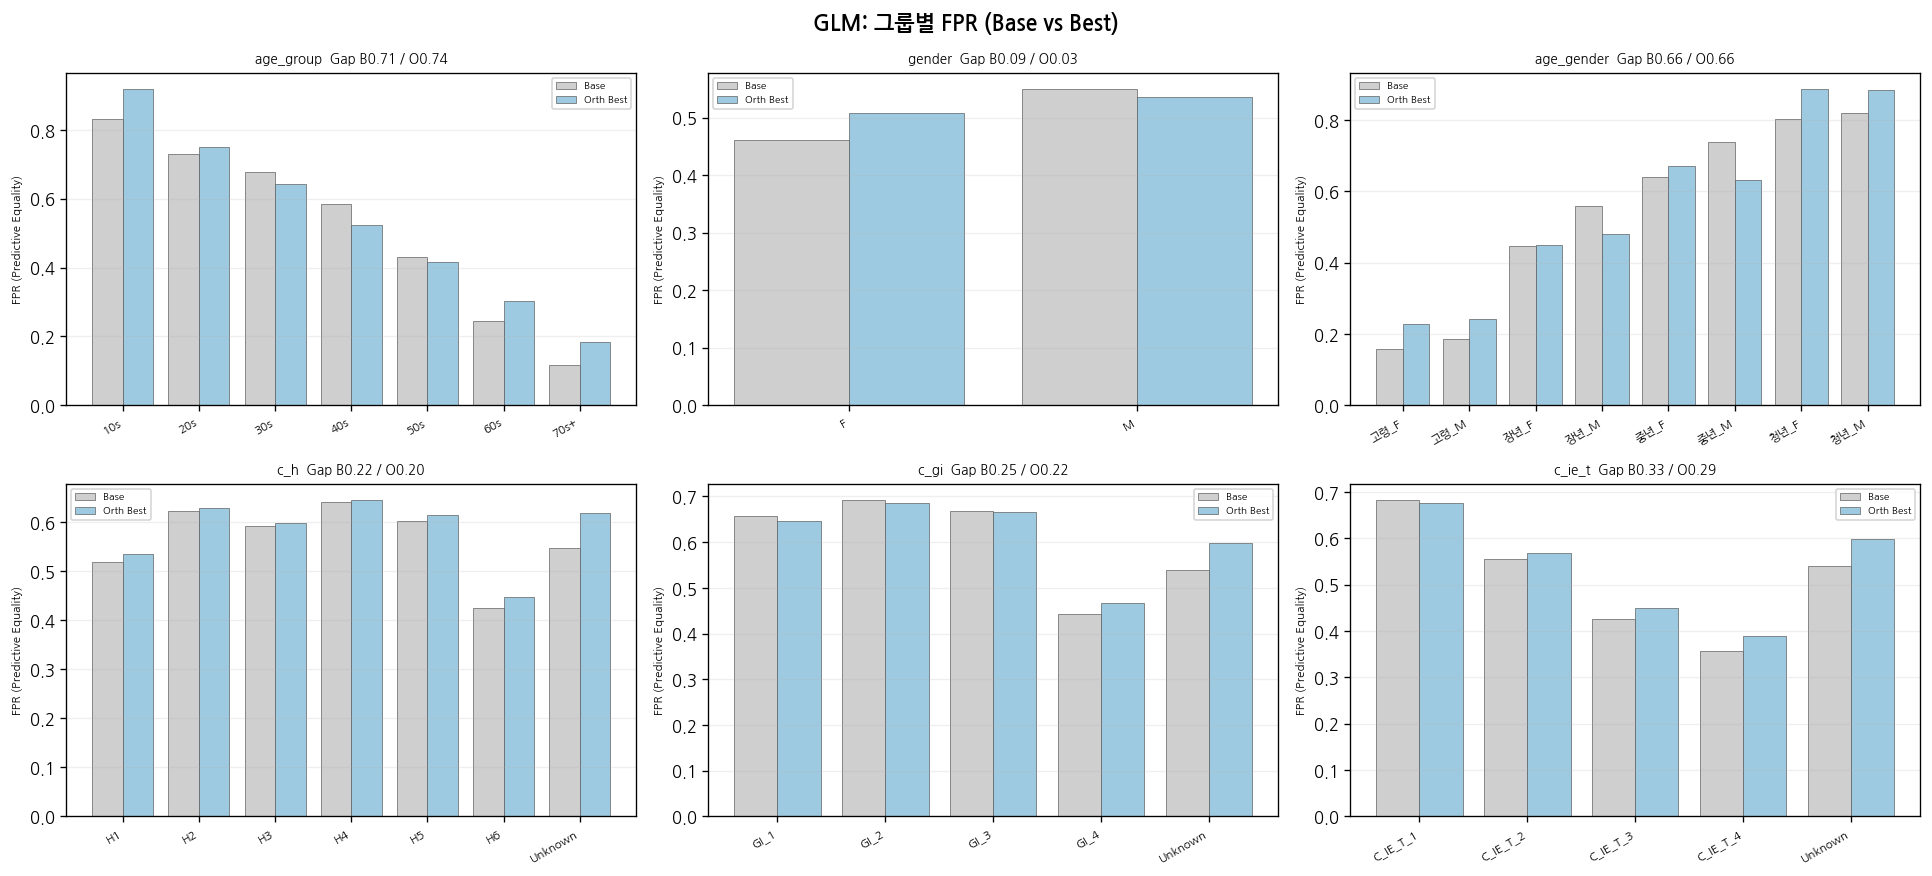

In [ ]:
best_method, best = pick_best_variant(orth_rows, cr_rows, 'EO Gap')
# 아래 EO Gap, F1은 '선택 기준'인 val(2018) 값 — 최종 test 수치는 custom 직교화 표 참고
print(f"GLM Best = {best_method} (τ={best['param']}) | 선택기준 val: EO Gap={best['EO Gap']:.4f}, F1={best['F1']:.4f}")
plot_group_bars(y_test, sensitive_test,
                [('Base', pred_glm_base), (f'{best_method} Best', best['pred'])],
                "GLM: 민감변수 그룹별 FPR (Base vs Best)", "group_glm.png", rate='fpr')

### Threshold Tuning (후처리 3방법)

직교화(전처리) best 모델 위에 그룹별 임계값을 조정하는 후처리. 민감변수별 표 6개 생성.
- **방법1) FPR 균등화 (gap 악화 시 revert)**: val(2018)에서 전체 FPR을 목표로 각 그룹 음성(y=0) 확률 분위수를 임계값으로. gap이 원래보다 커지면 (0.01↑) 그 변수는 공통 임계값으로 revert.
- **방법2) ThresholdOptimizer (fairlearn)**: `equalized_odds` 제약으로 val 그룹별 최적 threshold 학습 → test.
- **방법3) val-F1max**: 각 그룹에서 val F1을 최대화하는 임계값 → test.
- 후처리는 그룹별 threshold를 적용하므로 F1이 민감변수, 방법마다 달라짐.

In [ ]:
# 직교화 best 재적합
best_orth = best_feasible(orth_rows, 'EO Gap')
orth_cols = r2_glm_series[r2_glm_series > best_orth['param']].index.tolist()
X_tr_orth, X_te_orth = orthogonalize(x_train_glm, x_test_glm, orth_cols, basis_tr, basis_te,
                                     x_train_glm_num, x_test_glm_num)
orth_model = make_glm_pipeline()
orth_model.fit(X_tr_orth, y_train)
prob_test_orth = orth_model.predict_proba(X_te_orth)[:, 1]
prob_val_orth  = orth_model.predict_proba(X_tr_orth)[:, 1][val_mask]
pred_orth  = (prob_test_orth >= glm_thr).astype(int)
X_val_orth = X_tr_orth[val_mask]

,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.7195,0.7147,0.6237,0.3575
전처리 best (Orth),0.7211,0.7360,0.5108,0.3555
+FPR균등화,0.0438,0.0342,0.0990,0.3440
+ThresholdOpt(EO),0.0419,0.0373,0.0634,0.3569
+F1max,0.2359,0.2084,0.2042,0.3914


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.0817,0.0886,0.0429,0.3575
전처리 best (Orth),0.0236,0.0276,0.0011,0.3555
+FPR균등화,0.0074,0.0052,0.0213,0.3556
+ThresholdOpt(EO),0.0030,0.0061,0.0165,0.3863
+F1max,0.1149,0.1150,0.1108,0.3902


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.6663,0.6634,0.5162,0.3575
전처리 best (Orth),0.6467,0.6585,0.4191,0.3555
+FPR균등화,0.0384,0.0320,0.0510,0.3442
+ThresholdOpt(EO),0.0331,0.0337,0.0715,0.3586
+F1max,0.3082,0.2770,0.3059,0.3912


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.2139,0.2158,0.1450,0.3575
전처리 best (Orth),0.1933,0.1971,0.1010,0.3555
+FPR균등화,0.0293,0.0428,0.0577,0.3534
+ThresholdOpt(EO),0.0177,0.0325,0.1037,0.3551
+F1max,0.2485,0.2311,0.2033,0.3917


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.2576,0.2491,0.1791,0.3575
전처리 best (Orth),0.2296,0.2201,0.1534,0.3555
+FPR균등화,0.0862,0.0610,0.0616,0.3536
+ThresholdOpt(EO),0.0395,0.0143,0.0961,0.3721
+F1max,0.3238,0.2911,0.2777,0.3906


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.3364,0.3257,0.2657,0.3575
전처리 best (Orth),0.2971,0.2877,0.2153,0.3555
+FPR균등화,0.0481,0.0449,0.0343,0.3534
+ThresholdOpt(EO),0.0379,0.0290,0.0773,0.3698
+F1max,0.2965,0.2671,0.2903,0.3912


{'age_group':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.7195   0.7147   0.6237  0.3575
 전처리 best (Orth)    0.7211   0.7360   0.5108  0.3555
 +FPR균등화            0.0438   0.0342   0.0990  0.3440
 +ThresholdOpt(EO)  0.0419   0.0373   0.0634  0.3569
 +F1max             0.2359   0.2084   0.2042  0.3914,
 'gender':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.0817   0.0886   0.0429  0.3575
 전처리 best (Orth)    0.0236   0.0276   0.0011  0.3555
 +FPR균등화            0.0074   0.0052   0.0213  0.3556
 +ThresholdOpt(EO)  0.0030   0.0061   0.0165  0.3863
 +F1max             0.1149   0.1150   0.1108  0.3902,
 'age_gender':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.6663   0.6634   0.5162  0.3575
 전처리 best (Orth)    0.6467   0.6585   0.4191  0.3555
 +FPR균등

In [ ]:
# 후처리 방법 3가지
res_fpr = tune_thresholds_fpr(prob_val_orth, y_val, sensitive_val, prob_test_orth,
                              sensitive_test, glm_thr, rate='fpr')
res_eo  = tune_thresholds_equalized_odds(orth_model, X_val_orth, y_val, sensitive_val,
                                         X_te_orth, sensitive_test, fallback_pred=pred_orth)
res_f1  = tune_thresholds_f1max(prob_val_orth, y_val, sensitive_val, prob_test_orth,
                                sensitive_test, glm_thr)

per_variable_tables(y_test, sensitive_test, [
    ('Base', pred_glm_base),
    ('전처리 best (Orth)', pred_orth),
    ('+FPR균등화', res_fpr),
    ('+ThresholdOpt(EO)', res_eo),
    ('+F1max', res_f1),
], 'GLM', orth_tau=best_orth['param'])

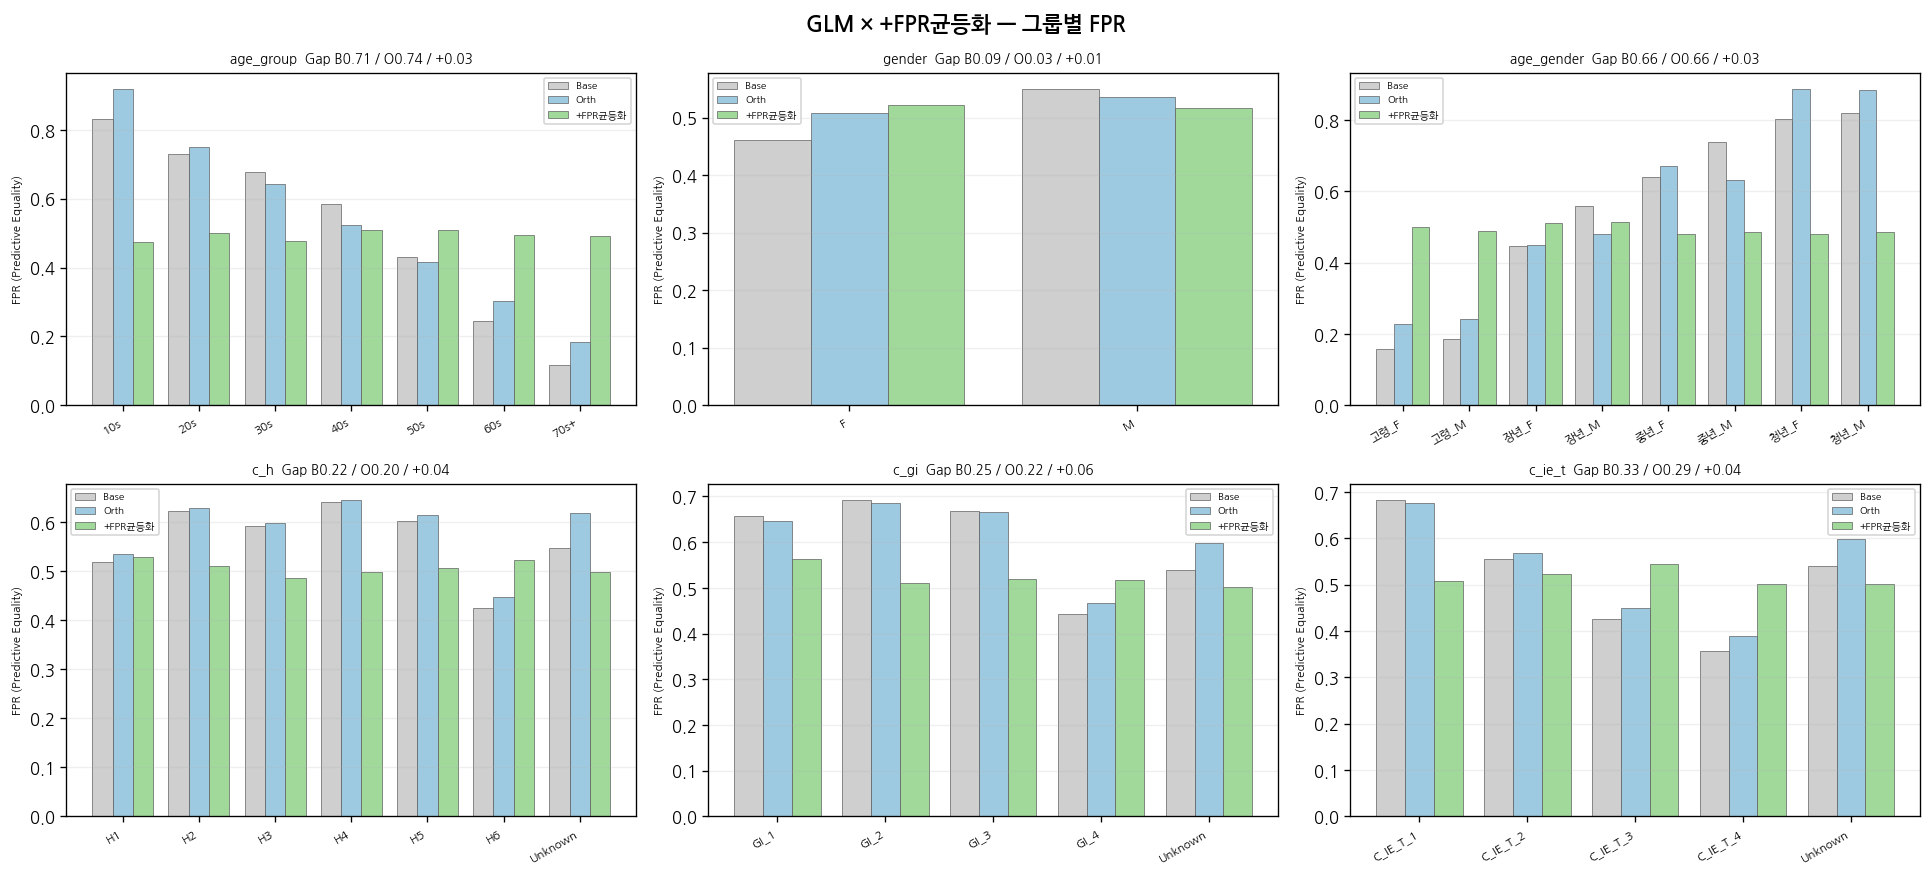

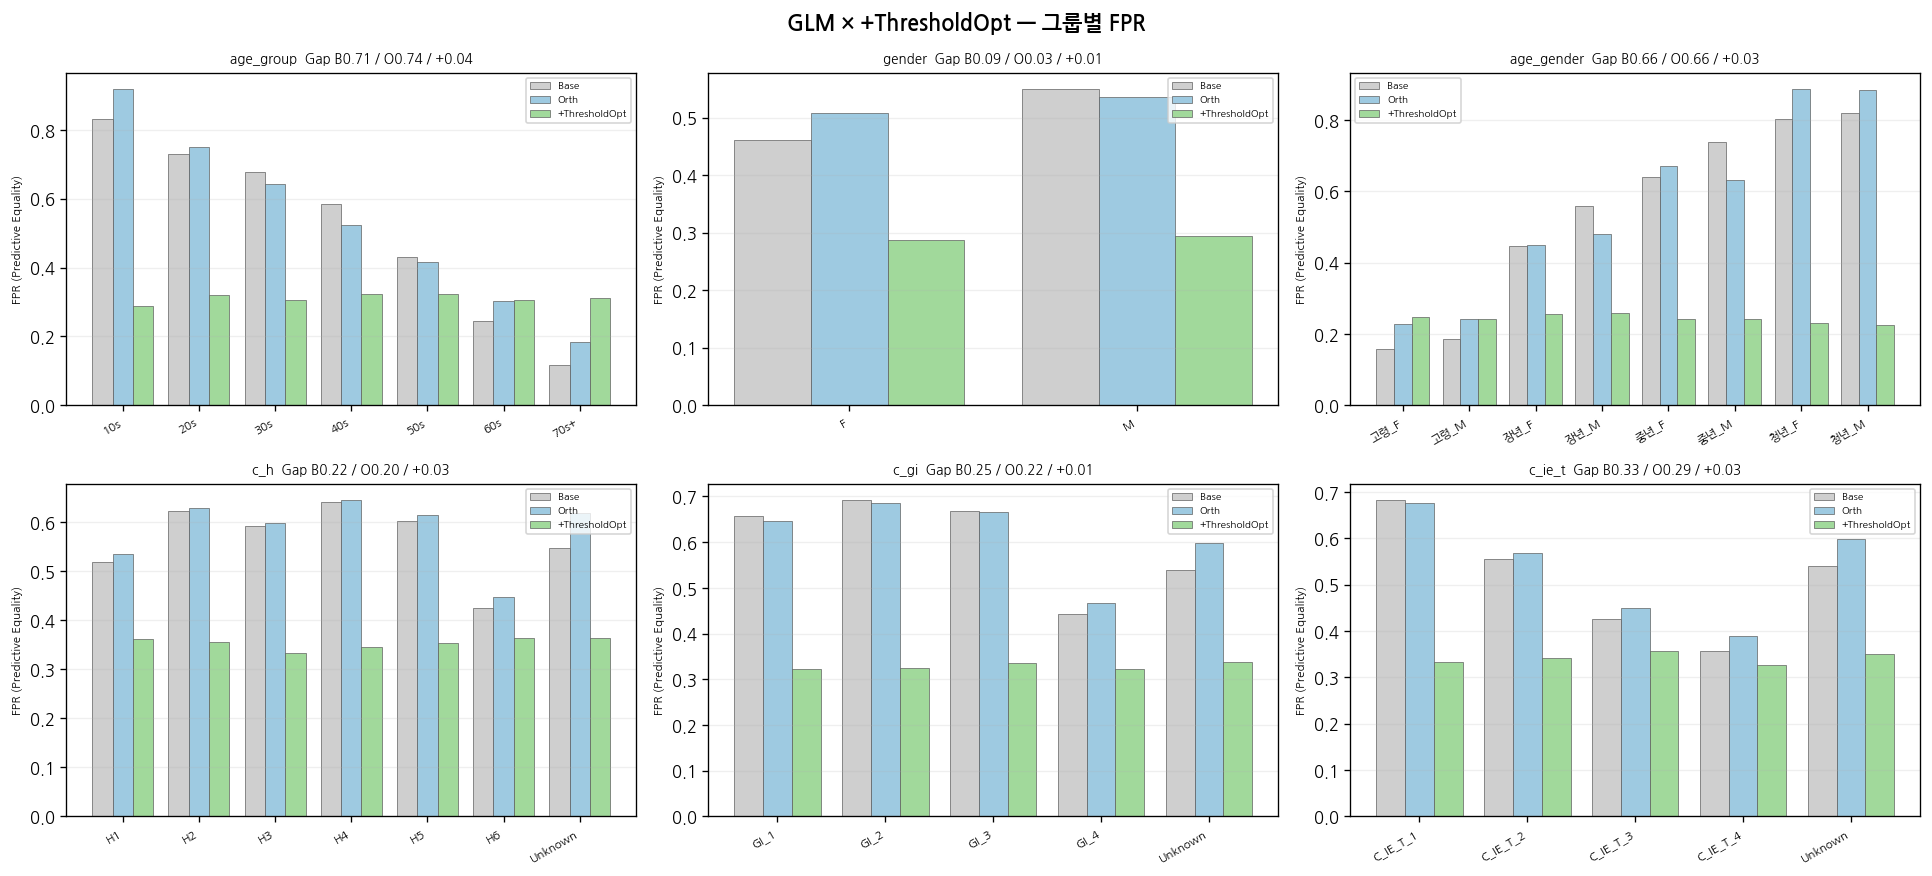

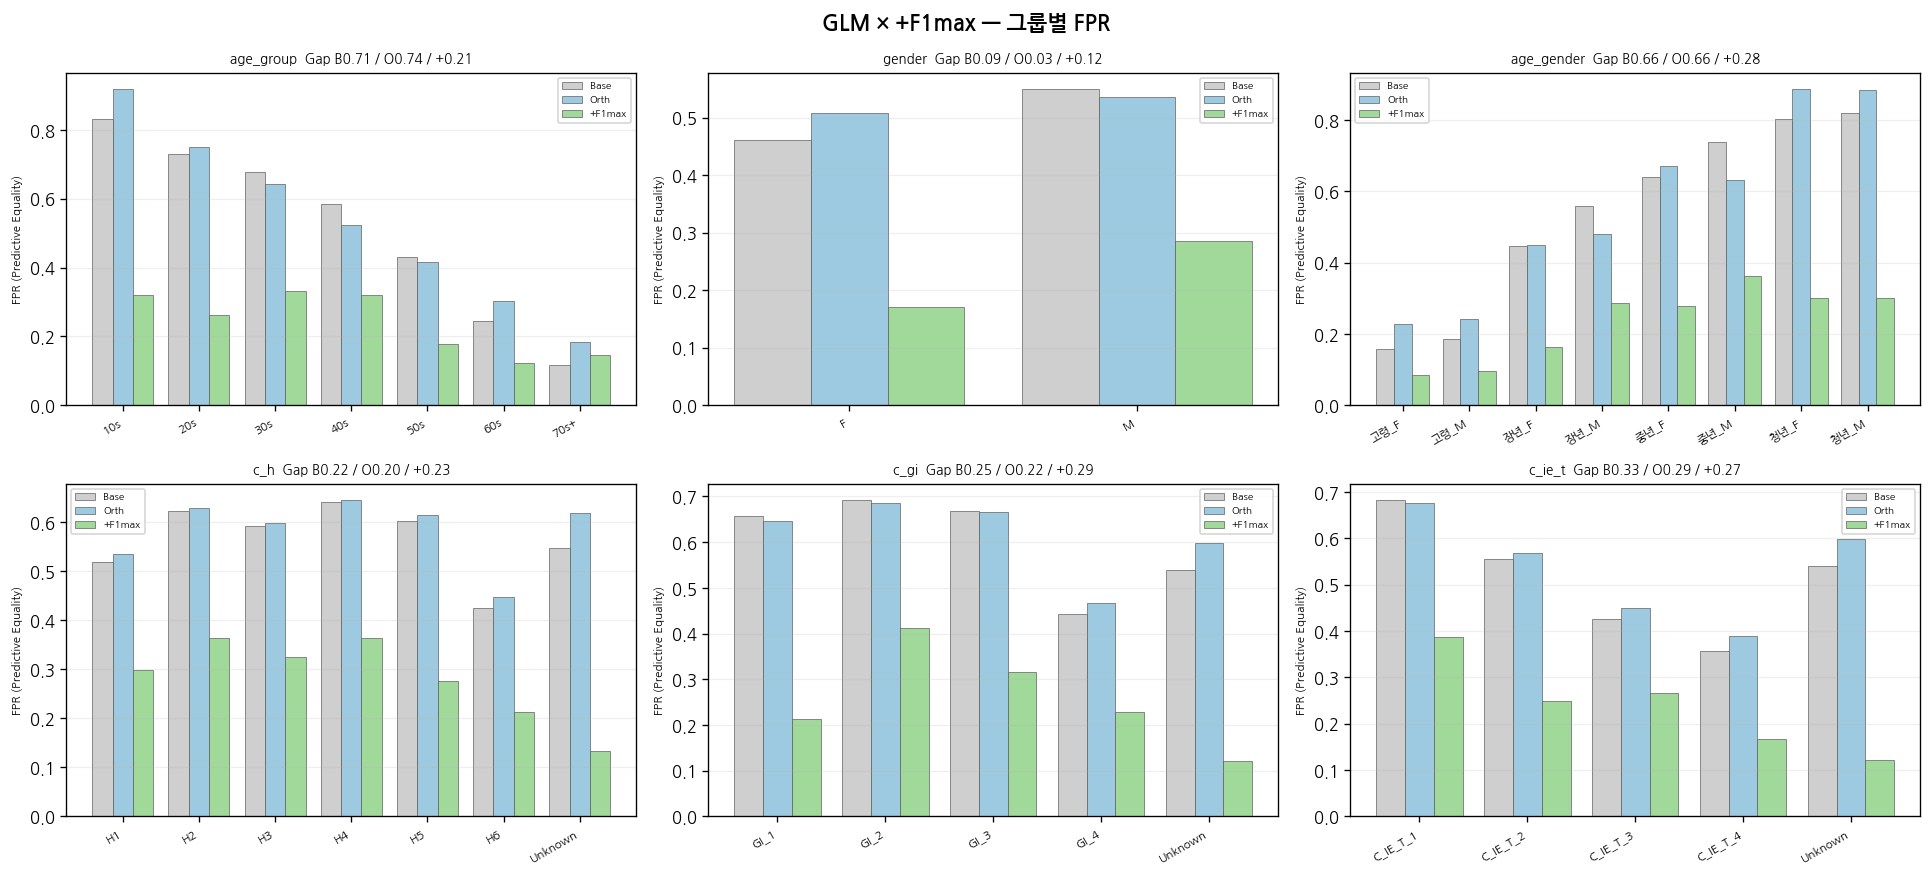

In [ ]:
# 시각화
for res, method, fname in [(res_fpr, '+FPR균등화', 'tt_glm_fpr.png'),
                           (res_eo, '+ThresholdOpt', 'tt_glm_to.png'),
                           (res_f1, '+F1max', 'tt_glm_f1.png')]:
    plot_group_bars(y_test, sensitive_test,
                    [('Base', pred_glm_base), ('Orth', pred_orth), (method, res)],
                    f"GLM × {method} — 그룹별 FPR", fname, rate='fpr')